In [11]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [12]:
class MoneyAgent(mesa.Agent):
    def __init__(self, model, ethnicity):
        super().__init__(model)
        self.wealth = 1
        self.ethnicity = ethnicity

    def exchange(self):
        if self.wealth > 0:
            other_agent = self.random.choice(self.model.agents)
            other_agent.wealth += 1
            self.wealth -= 1

In [13]:
class MoneyModel(mesa.Model):
    def __init__(self, n=10):
        super().__init__()
        ethnicities = [self.random.choice(["Green", "Blue", "Mixed"]) for _ in range(n)]
        MoneyAgent.create_agents(model=self, n=n, ethnicity=ethnicities)

    def step(self):
        self.agents.shuffle_do("exchange")

In [14]:
model = MoneyModel(10)  # Tells the model to create 10 agents
for _ in range(30):  # Runs the model for 30 steps;
    model.step()

# Note: An underscore is common convention for a variable that is not used.

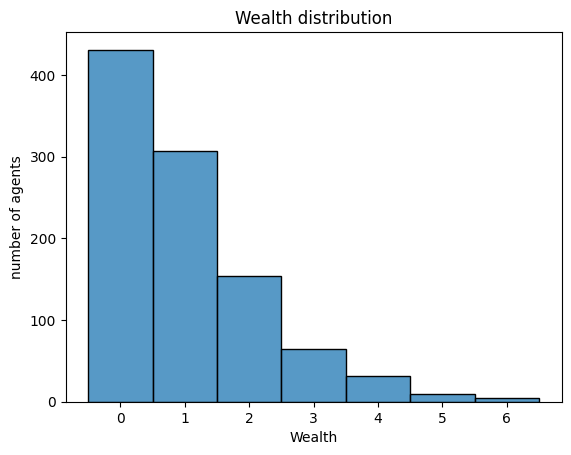

In [15]:
all_wealth = []
# This runs the model 100 times, each model executing 30 steps.
for _ in range(100):
    # Run the model
    model = MoneyModel(10)
    model.run_for(30)

    # Store the results
    for agent in model.agents:
        all_wealth.append(agent.wealth)

# Use seaborn
g = sns.histplot(all_wealth, discrete=True)
g.set(title="Wealth distribution", xlabel="Wealth", ylabel="number of agents");

In [16]:
model = MoneyModel(100)
model.run_for(50)

In [17]:
# How many agents are in the model?
print(f"Total agents: {len(model.agents)}")

# Iterate over agents (just the first 5 for brevity)
for agent in model.agents.select(at_most=5):
    print(
        f"  Agent {agent.unique_id}: wealth={agent.wealth}, ethnicity={agent.ethnicity}"
    )

Total agents: 100
  Agent 1: wealth=1, ethnicity=Blue
  Agent 2: wealth=0, ethnicity=Blue
  Agent 3: wealth=0, ethnicity=Blue
  Agent 4: wealth=1, ethnicity=Mixed
  Agent 5: wealth=3, ethnicity=Blue


In [18]:
# Get all wealth values
all_wealth = model.agents.get("wealth")
print(f"First 10 wealth values: {all_wealth[:10]}")
print(f"Total wealth in economy: {sum(all_wealth)}")

First 10 wealth values: [1, 0, 0, 1, 3, 1, 0, 0, 1, 0]
Total wealth in economy: 100


In [19]:
# Get both wealth and ethnicity for each agent
wealth_and_ethnicity = model.agents.get(["wealth", "ethnicity"])
print("First 5 agents (wealth, ethnicity):")
for values in wealth_and_ethnicity[:5]:
    print(f"  {values}")

First 5 agents (wealth, ethnicity):
  [1, 'Blue']
  [0, 'Blue']
  [0, 'Blue']
  [1, 'Mixed']
  [3, 'Blue']


In [20]:
# Select only wealthy agents (wealth >= 3)
rich_agents = model.agents.select(lambda a: a.wealth >= 3)
print(f"Rich agents (wealth >= 3): {len(rich_agents)}")

# Select agents with no money
broke_agents = model.agents.select(lambda a: a.wealth == 0)
print(f"Broke agents (wealth == 0): {len(broke_agents)}")

Rich agents (wealth >= 3): 10
Broke agents (wealth == 0): 39


In [21]:
# In this model we only have one type, but the syntax would be:
money_agents = model.agents.select(agent_type=MoneyAgent)
print(f"MoneyAgents: {len(money_agents)}")

MoneyAgents: 100


In [22]:
# Get at most 5 rich agents
some_rich = model.agents.select(lambda a: a.wealth >= 2, at_most=5)
print(f"Up to 5 rich agents: {len(some_rich)}")

# Get roughly 10% of agents
ten_percent = model.agents.select(at_most=0.1)
print(f"~10% of agents: {len(ten_percent)}")

Up to 5 rich agents: 5
~10% of agents: 10


In [23]:
# Group agents into wealth brackets
def wealth_bracket(agent):
    if agent.wealth == 0:
        return "broke"
    elif agent.wealth <= 2:
        return "modest"
    else:
        return "wealthy"


brackets = model.agents.groupby(wealth_bracket)
print("Agents per wealth bracket:", brackets.count())

Agents per wealth bracket: {'modest': 51, 'broke': 39, 'wealthy': 10}


In [24]:
print("=== Model Summary After 50 Steps ===\n")

# Overall statistics
min_w, max_w, avg_w, total_w = model.agents.agg("wealth", [min, max, np.mean, sum])
print(f"Agents: {len(model.agents)}")
print(
    f"Total wealth: {total_w} (conserved: {'yes' if total_w == len(model.agents) else 'no, subsidy applied'})"
)
print(f"Wealth range: {min_w} to {max_w}, mean: {avg_w:.2f}\n")

# By ethnicity
print("By ethnicity:")
for ethnicity, group in model.agents.groupby("ethnicity"):
    count = len(group)
    avg = group.agg("wealth", np.mean)
    broke = len(group.select(lambda a: a.wealth == 0))
    print(
        f"  {ethnicity:6s}: {count:3d} agents, avg wealth = {avg:.2f}, broke = {broke}"
    )

# Wealth distribution
print("\nWealth brackets:")
for bracket, group in model.agents.groupby(wealth_bracket):
    print(f"  {bracket:8s}: {len(group)} agents")

=== Model Summary After 50 Steps ===

Agents: 100
Total wealth: 100 (conserved: yes)
Wealth range: 0 to 5, mean: 1.00

By ethnicity:
  Blue  :  42 agents, avg wealth = 1.05, broke = 14
  Mixed :  24 agents, avg wealth = 1.04, broke = 9
  Green :  34 agents, avg wealth = 0.91, broke = 16

Wealth brackets:
  modest  : 51 agents
  broke   : 39 agents
  wealthy : 10 agents


[Text(0.5, 1.0, 'Wealth distribution by ethnicity'),
 Text(0.5, 0, 'Wealth'),
 Text(0, 0.5, 'Number of agents')]

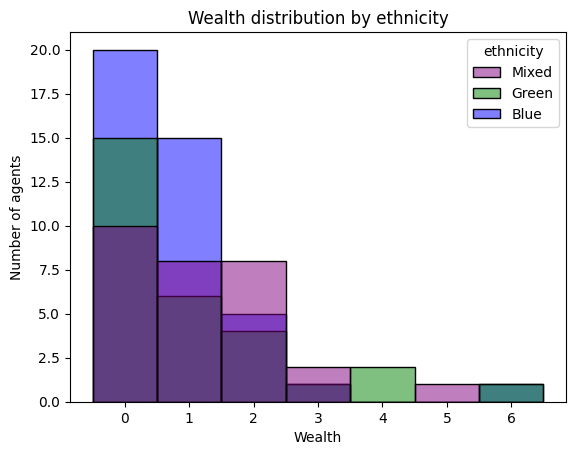

In [25]:
# Collect data for plotting
model = MoneyModel(100)
model.run_for(50)

data = []
for agent in model.agents:
    data.append({"wealth": agent.wealth, "ethnicity": agent.ethnicity})
df = pd.DataFrame(data)

palette = {"Green": "green", "Blue": "blue", "Mixed": "purple"}
g = sns.histplot(data=df, x="wealth", hue="ethnicity", discrete=True, palette=palette)
g.set(
    title="Wealth distribution by ethnicity", xlabel="Wealth", ylabel="Number of agents"
)